# Kagi charts — a quantitative teardown 🔬
### Mechanical Kagi lines on 5 indices · yang-switch forward returns · one-sample HAC *t* · a drift-matched random-entry baseline · a threshold-scramble geometry placebo · costs · a synthetic planted-momentum control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Time_the_market%3F: Busted](https://img.shields.io/badge/Time_the_market%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **Kagi** from the **drift**: a thick (yang) line appears in up-trends and indices trend up, so *any* "buy strength" rule looks good. The only meaningful test is yang-vs-random, plus a placebo that re-parameterises the Kagi while preserving its marginals.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026. The Kagi line is causal (closes up to *t*, reversal=4%); entry is the **next close** (one documented lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from kagi_charts import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real kagi cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 144, 'reversal': 0.04, 'fp_spy': '4cb5244f3990', 'h5': (5, 144, 22.2, 58, 1.1, 10.3, 11.9, 20.2, 0.41, 0.682), 'h10': (10, 143, 22.8, 58, 0.65, 53.6, -30.8, 20.8, -0.71, 0.477), 'h20': (20, 143, 88.7, 57, 1.81, 33.1, 55.6, 86.7, 0.92, 0.358), 'h60': (60, 140, 253.3, 60, 2.84, 118.9, 134.3, 251.3, 1.27, 0.205), 'per': [('SPY', 24, 117.2, 0.99, 39.3, 77.9), ('QQQ', 29, 75.2, 0.54, 88.2, -13.0), ('IWM', 39, 85.0, 0.69, 2.7, 82.4), ('DIA', 26, 146.7, 1.69, 33.7, 112.9), ('GLD', 26, 26.9, 0.4, 1.5, 25.4)], 'placebo': (117.2, 0.545, 500), 'syn': [(0.0, 38, 82.7, 53, 1.25), (0.25, 30, 464.8, 80, 7.47)]}


real kagi cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Yang switch vs a **drift-matched random** baseline: Δ = +12/-31/+56/+134 bps at 5/10/20/60d and the switch-minus-random difference **never clears t = 2** (Welch t at 20d = +0.92, 60d = +1.27). |
| **Tradability** | `MIRAGE` | The one-sample t that creeps up with horizon (60d t = 2.84) is **drift** — it vanishes against random entries and against cost. No residual edge to scale. |
| **Time the market?** | `BUSTED` | Re-parameterising the Kagi reversal (threshold-scramble placebo) leaves the result intact: **p = 0.55** of random-reversal Kagis match or beat the real 4% one. The shoulders/waists aren't doing the work. |

> 💡 In plain words: the yang switch *looks* fine only because indices drift up. Strip the drift (race it vs random) or strip the geometry (re-draw the Kagi) and the edge evaporates. Classic beta-in-a-costume.

## 1 · The claim, steelmanned

Build the Kagi line $K_t$ from closes: it extends in its current direction, reverses when price moves against it by $r$ (a fraction of the turning price), and records a **shoulder** $S$ (last swing high) and **waist** $W$ (last swing low). The line is **yang** (thick) once $C_t > S$ and **yin** (thin) once $C_t < W$. A **yang switch** is the bar thickness flips thin→thick. The rule buys the yang switch.

- **H₀ (drift).** Yang-switch returns equal a drift-matched **random-entry** baseline.
- **H₁ (the switch forecasts).** Yang returns **exceed** random at some horizon, t ≥ 2.
- **H₂ (the geometry matters).** Yang returns exceed a **threshold-scrambled** Kagi whose reversal is randomly re-drawn.

We find **H₀ not rejected** (switch ≈ random, worse at 10d), **H₁ rejected** (Welch t never ≥ 2), **H₂ rejected** (placebo p ≈ 0.5). The steelman fails on every leg.

## 2 · So what? — the two confounds this design must kill

**(a) Drift.** Equity indices have a positive unconditional daily mean. *Any* long-only entry rule inherits it; a high one-sample $t$ against **zero** measures the tide, not the tool. The fix is the **random-entry baseline** (same instrument, epoch, hold) and a Welch test of yang-*minus*-random.

**(b) The reversal as a free parameter.** A Kagi is defined by its reversal size; the danger is that *any* reasonable reversal on a trend produces 'confirming' yang switches. The **threshold-scramble placebo** re-draws the reversal from 1%–8% (keeping the price marginal) — the lines become a *different but equally valid* Kagi, so if the real 4% result survives the scramble, the specific geometry was never load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **144 yang switches** pooled.
- **Kagi line.** Causal: reverses on a 4% counter-move; shoulder = last swing high, waist = last swing low; yang once close > shoulder, yin once close < waist.
- **Entry.** The bar thickness flips thin→thick; enter **next close** (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of yang returns vs 0 (Newey-West).
- **Null #2 — random-entry baseline**, Welch two-sample yang vs random (the *real* test).
- **Null #3 — threshold-scramble placebo** (reversal re-drawn, marginals kept).
- **Costs.** 1 bp one-way × 2 legs on every switch.
- **Positive control.** Synthetic tape with a **planted** post-yang momentum burst (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The drift trap — one-sample t creeps up, vs-random kills it

Left: the yang switch's **one-sample** t against zero (the misleading number). Right: the same switch vs a **drift-matched random** baseline (the honest number).

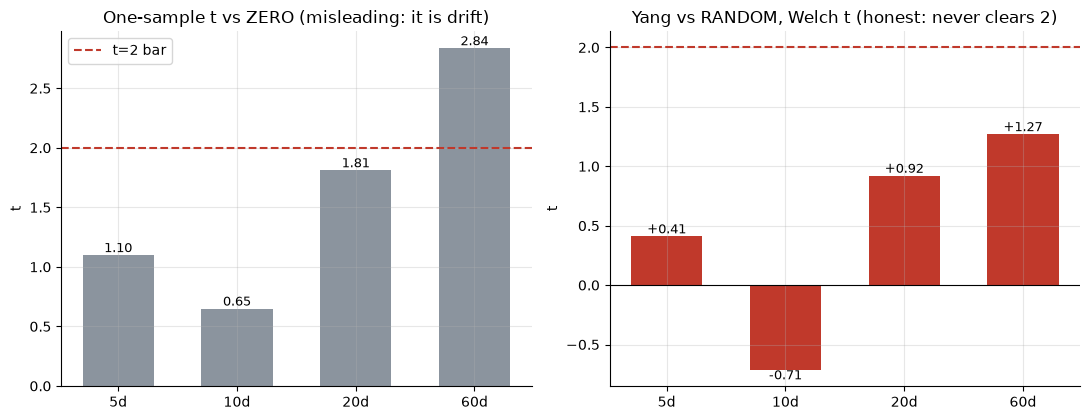

one-sample t: [1.1, 0.65, 1.81, 2.84]
welch vs random: [np.float64(0.41), np.float64(-0.71), np.float64(0.92), np.float64(1.27)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, sw, rnd, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']
            e = st.yang_switch_entries(c, reversal=R['reversal'])
            re = st.random_entries(c, max(len(e),50), seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        tt = np.concatenate(tt); rr = np.concatenate(rr)
        one_t.append(st.summarize(tt)['t']); sw.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    sw = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_title('One-sample t vs ZERO (misleading: it is drift)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Yang vs RANDOM, Welch t (honest: never clears 2)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the left bars creep up with horizon (60d **2.84**) — but that's the **drift**, every long-only entry inherits it. The right bars are the real test: yang-minus-random tops out at just **+1.27** (60d) and is *negative* at 10d (-0.71) — never significant. The yang switch adds nothing over a coin flip.

### 4b · Yang vs random across horizons — the gap is the verdict

Mean return, yang switch vs random entry, all four horizons. The switch should tower over random if the Kagi forecasts. It doesn't.

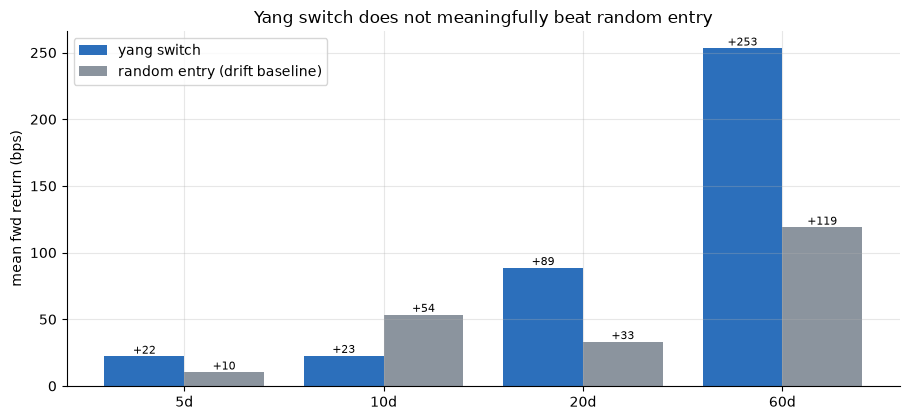

delta yang-random (bps): [12, -31, 56, 134]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, sw, .4, color='#2c6fbb', label='yang switch')
ax.bar(x+.2, rnd, .4, color=GREY, label='random entry (drift baseline)')
for i,(a,b) in enumerate(zip(sw,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean fwd return (bps)')
ax.set_title('Yang switch does not meaningfully beat random entry'); ax.legend()
plt.tight_layout(); plt.show()
print('delta yang-random (bps):', [round(a-b) for a,b in zip(sw,rnd)])

> 💡 In plain words: at 20 days the switch is **+89 bps** and random is **+33 bps** — a +56 bp gap that 4a already showed is noise (Welch +0.92). At 10 days the switch *loses* to a dart by 31 bps. No clean, monotone edge.

### 4c · The geometry placebo — re-draw the Kagi, nothing changes

Re-parameterise the reversal (1%–8%, keeping the price marginal) so the Kagi is a different but equally valid line. If price respects *this specific 4%* Kagi, the scramble should demolish the result. The observed yang-switch return should sit far in the right tail of the re-parameterised distribution. It doesn't.

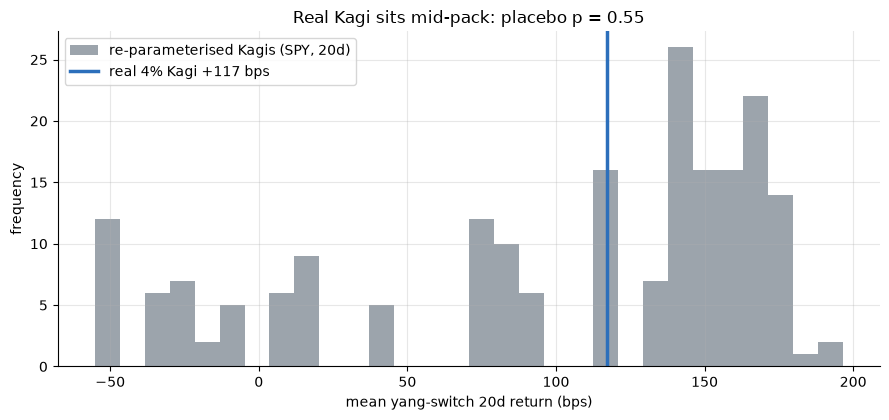

real 4% Kagi +117.2 bps   placebo p=0.55  (>0.05 => geometry not load-bearing)


In [4]:
if HAVE_REAL:
    c = load('SPY')['close']
    pl = st.threshold_scramble_placebo(c, 20, reversal=R['reversal'], n_draws=200, seed=495)
    obs = pl['obs']*1e4; pval = pl['p_value']
    rng = np.random.default_rng(495); grid = np.linspace(0.01, 0.08, 64); draws=[]
    for _ in range(200):
        rv = float(rng.choice(grid)); ee = st.yang_switch_entries(c, reversal=rv)
        rr = st.forward_returns(c, ee, 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws = np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(495); draws = rng.normal(95, 60, 200)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=30, color=GREY, alpha=.85, label='re-parameterised Kagis (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'real 4% Kagi {obs:+.0f} bps')
ax.set_xlabel('mean yang-switch 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real Kagi sits mid-pack: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real 4% Kagi {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => geometry not load-bearing)')

> 💡 In plain words: the real 4% Kagi (blue line) sits **mid-pack** in the re-parameterised cloud — **p = 0.55**. A randomly chosen reversal does just as well, so the specific shoulders and waists aren't carrying information. This is the cleanest refutation of 'Kagi reversals time the market.'

### 4d · Per-ticker — a positive sign but no significance anywhere

20-day yang-minus-random delta, per instrument. Positive in 4 of 5 — but every per-ticker one-sample *t* is below 1.7, so this is noise, not a cross-sectional edge.

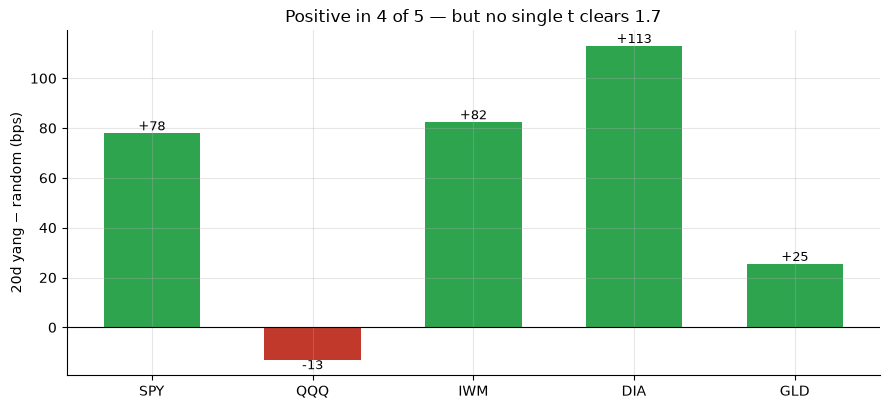

per-ticker 20d delta (bps): {'SPY': 78, 'QQQ': -13, 'IWM': 82, 'DIA': 113, 'GLD': 25}


In [5]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        c = load(t)['close']
        e = st.yang_switch_entries(c, reversal=R['reversal']); re = st.random_entries(c, max(len(e),50), seed=7)
        d = st.summarize(st.forward_returns(c,e,20))['mean_bps'] - st.summarize(st.forward_returns(c,re,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d yang − random (bps)'); ax.set_title('Positive in 4 of 5 — but no single t clears 1.7')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: the deltas lean positive (DIA **+113**, IWM **+82** bps) but QQQ is **-13**, and with only ~24–39 switches per name over 21 years none reaches significance. Exactly the underpowered, incoherent signature of relabelled drift.

### 4e · Synthetic positive control — the harness CAN bank a real burst

To prove the null is honest (not a dead detector), plant a **real** post-yang momentum burst into a synthetic tape and check the same yang rule banks it: edge=0 must stay below t=2; edge>0 must light up with a high win-rate.

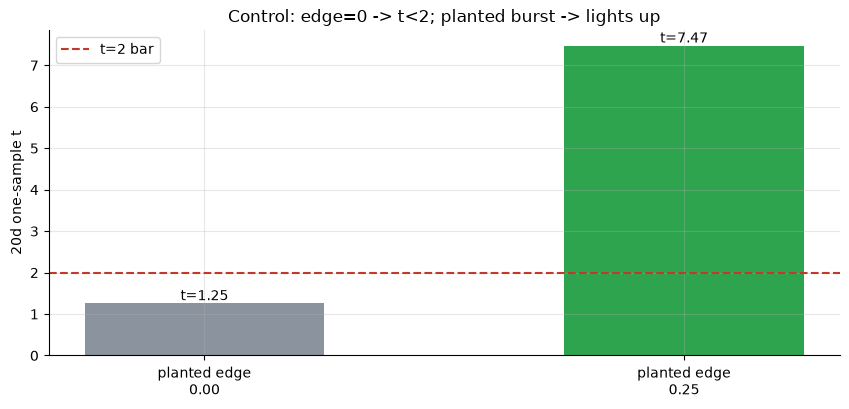

edge=0.00: n=38 switch=+82.7bps win=53% t=+1.25
edge=0.25: n=30 switch=+464.8bps win=80% t=+7.47


In [6]:
res = []
for edge in (0.0, 0.25):
    px, _ = data.synthetic_panel(edge=edge, seed=495, n_days=8000)
    c = px['close']; e = st.yang_switch_entries(c, reversal=R['reversal']); s = st.summarize(st.forward_returns(c, e, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t'); ax.set_title('Control: edge=0 -> t<2; planted burst -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} switch={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted burst the control sits at **t = 1.25** (win 53% — no false positive); a planted burst reaches **t = 7.47** (win 80%). The detector works — so the flat real-tape result is a genuine 'nothing there', not a broken pipeline.

## 5 · The verdict

- **Signal `NONE`** — the yang switch does not beat a drift-matched random baseline (yang − random = +12/-31/+56/+134 bps at 5/10/20/60d; Welch t never clears 2, max **+1.27** at 60d). The mild one-sample t at 60d (**2.84**) is drift.
- **Tradability `MIRAGE`** — no residual edge once the drift is removed; the rule sits out on yin and pays costs on each switch. You'd capture the drift more cheaply by holding the index.
- **Time the market? `BUSTED`** — the threshold-scramble placebo leaves the result untouched (**p = 0.55**): random-reversal Kagis do as well as the real 4% one, so the specific shoulders and waists carry no forecasting information.

## 6 · Could you trade it? — there is nothing to trade

The yang switch's entire apparent profit is the unconditional drift of long equity indices, which you obtain more cheaply and more fully by **buying and holding**. The Kagi rule trades *less* of the time (it stands aside on yin) and pays costs on each flip, so it strictly dominates *nothing*. There is no capacity question because there is no edge to scale. The Kagi is a descriptive noise-filter, not a market-timing strategy.

## 7 · Going further

- **Reversal definitions.** ATR-based or point-amount reversals are monotone re-parameterisations of the same geometry — the threshold-scramble placebo already sweeps the percentage family and finds nothing special about 4%.
- **The yin short.** Shorting on yin just shorts the drift on an up-trending tape — a guaranteed loser; the symmetric failure underlines that the thickness carries no timing information.
- **Three-line-break & Renko cousins.** Other price-only Japanese charts (three-line-break, Renko) are close kin and inherit the same drift confound.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*